# Pearls AQI Predictor - Exploratory Data AnalysisThis notebook is the exploratory analysis behind the forecasting system. It reads the**same feature store the training pipeline reads** (`aqi.data.store.read_features`), soevery number here is the data the model is actually trained on - nothing is re-derivedor hand-copied.**What the analysis established, and what each finding changed in the design:**| Finding | Consequence for the system ||---|---|| The cities differ by more than 2x in mean AQI | Justifies multi-city scope; Faisalabad, not Lahore, is worst || A strong winter peak | Cyclical month encoding; drift monitoring expected to fire seasonally || A strong daily cycle | Cyclical hour encoding; an hourly view is genuinely useful to a user || No single weather driver dominates | A non-linear model with interactions, not a linear one || The target is right-skewed | Empirical residual quantiles for intervals, not a symmetric Gaussian |Reproduce the figures outside the notebook with `python -m aqi.eda`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aqi.data.store import read_features
from aqi.data.aqi import AQI_CATEGORIES

pd.set_option("display.width", 110)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Load the feature storeThe same read the training pipeline performs.

In [2]:
df = read_features()
df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour

print(f"rows      : {len(df):,}")
print(f"cities    : {df['city'].nunique()}")
print(f"columns   : {df.shape[1]}")
print(f"date range: {df['datetime'].min():%Y-%m-%d} -> {df['datetime'].max():%Y-%m-%d}")
print(f"per city  : ~{len(df) // df['city'].nunique():,} hourly rows")

2026-09-01 23:56:45 | WARNING | aqi.data.store | hopsworks not installed here — reading from local Parquet store.


rows      : 696,960
cities    : 22
columns   : 74


date range: 2023-01-01 -> 2026-08-12
per city  : ~31,680 hourly rows


## 2. What is being predictedThe target is the US EPA Air Quality Index, divided into six health categories.

In [3]:
print(f"{'category':<32}{'range':<12}{'share of hours':>15}")
for c in AQI_CATEGORIES:
    share = ((df["aqi"] >= c.lo) & (df["aqi"] <= c.hi)).mean()
    print(f"{c.name:<32}{f'{c.lo}-{c.hi}':<12}{share:>14.1%}")
print(f"\nmean AQI {df['aqi'].mean():.1f} | median {df['aqi'].median():.1f} | max {df['aqi'].max():.0f}")

category                        range        share of hours
Good                            0-50                  2.2%
Moderate                        51-100               47.5%
Unhealthy for Sensitive Groups  101-150              28.8%
Unhealthy                       151-200              18.1%
Very Unhealthy                  201-300               3.0%
Hazardous                       301-500               0.3%

mean AQI 111.8 | median 101.0 | max 1020


### 2.1 Distribution of the targetA long right tail: mostly moderate-to-unhealthy air, with excursions into the hazardous band.

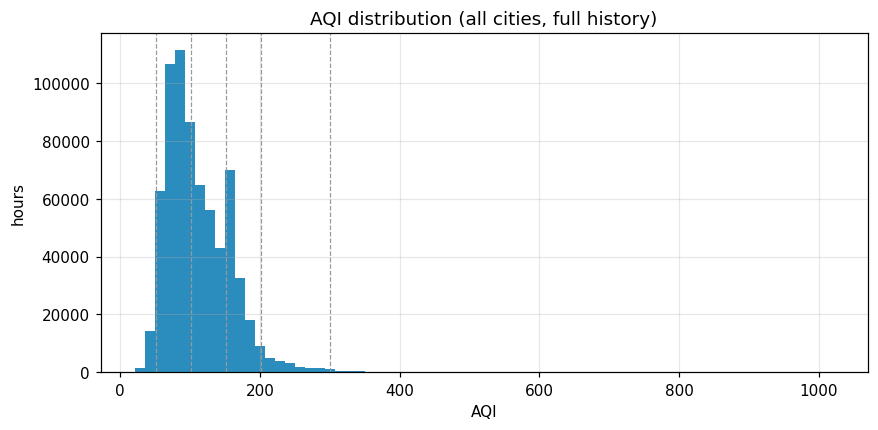

skew: 1.74 -> a symmetric interval would misdescribe the error; use empirical quantiles


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["aqi"].dropna(), bins=70, color="#2b8cbe")
for c in AQI_CATEGORIES[1:]:
    ax.axvline(c.lo, color="#999", lw=0.8, ls="--")
ax.set(title="AQI distribution (all cities, full history)", xlabel="AQI", ylabel="hours")
plt.show()

print("skew:", round(float(df["aqi"].skew()), 2),
      "-> a symmetric interval would misdescribe the error; use empirical quantiles")

## 3. The cities differ enormouslyThe single most important argument for the project's multi-city scope.

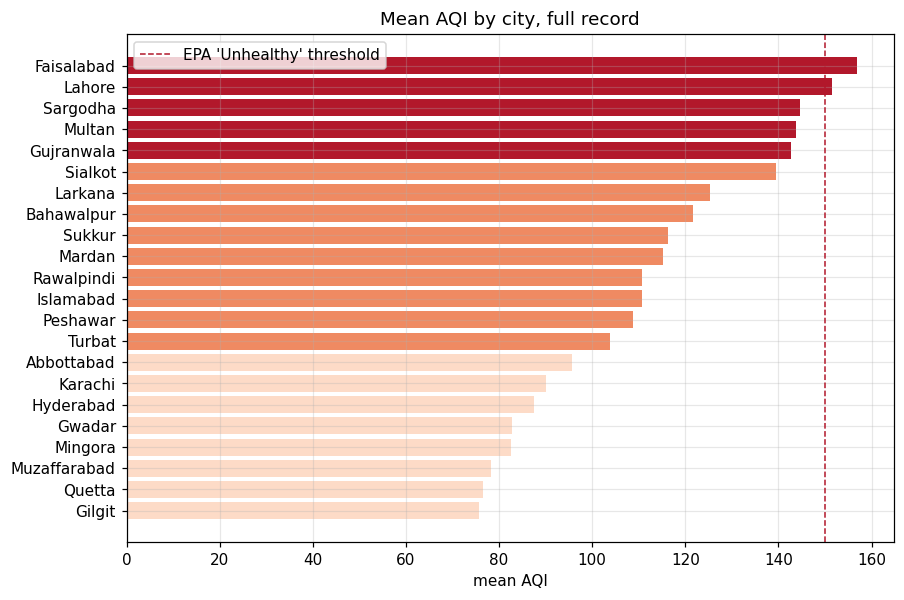

most polluted : Faisalabad (156.9)
cleanest      : Gilgit (75.7)
ratio         : 2.07x
cities with a MEAN above 140: 5


In [5]:
city_mean = df.groupby("city")["aqi"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#b2182b" if v > 140 else "#ef8a62" if v > 100 else "#fddbc7" for v in city_mean.values[::-1]]
ax.barh(city_mean.index[::-1], city_mean.values[::-1], color=colors)
ax.axvline(150, color="#b2182b", ls="--", lw=1, label="EPA 'Unhealthy' threshold")
ax.set(title="Mean AQI by city, full record", xlabel="mean AQI")
ax.legend()
plt.show()

print(f"most polluted : {city_mean.index[0]} ({city_mean.iloc[0]:.1f})")
print(f"cleanest      : {city_mean.index[-1]} ({city_mean.iloc[-1]:.1f})")
print(f"ratio         : {city_mean.iloc[0] / city_mean.iloc[-1]:.2f}x")
print(f"cities with a MEAN above 140: {(city_mean > 140).sum()}")

## 4. Seasonality is the dominant signalThe winter smog season: temperature inversions trap emissions under a shallow mixing layer.

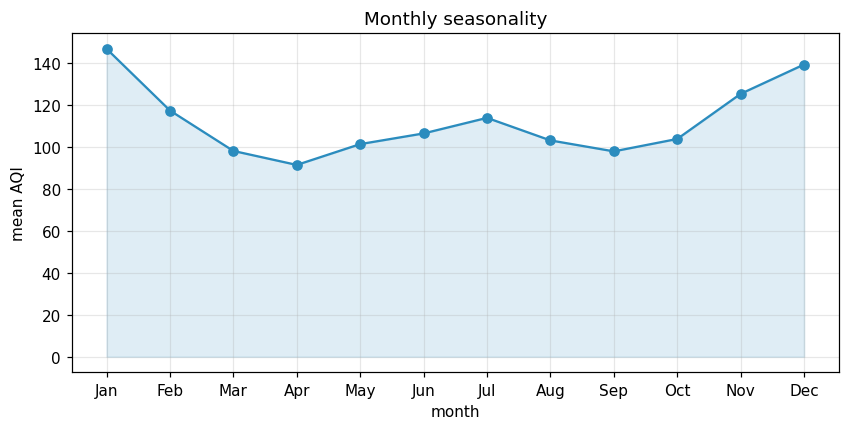

worst month : Jan (146.8)
best month  : Apr (91.5)
winter/summer ratio: 1.25x  -> strong recurring drift is expected


In [6]:
monthly = df.groupby("month")["aqi"].mean()
names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values, "-o", color="#2b8cbe")
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color="#2b8cbe")
ax.set(title="Monthly seasonality", xlabel="month", ylabel="mean AQI",
       xticks=range(1, 13), xticklabels=names)
plt.show()

winter = monthly.loc[[12, 1, 2]].mean()
summer = monthly.loc[[6, 7, 8]].mean()
print(f"worst month : {names[int(monthly.idxmax()) - 1]} ({monthly.max():.1f})")
print(f"best month  : {names[int(monthly.idxmin()) - 1]} ({monthly.min():.1f})")
print(f"winter/summer ratio: {winter / summer:.2f}x  -> strong recurring drift is expected")

## 5. A pronounced daily cycleWhy the dashboard offers an hourly view: within a bad day there are materially cleaner hours.

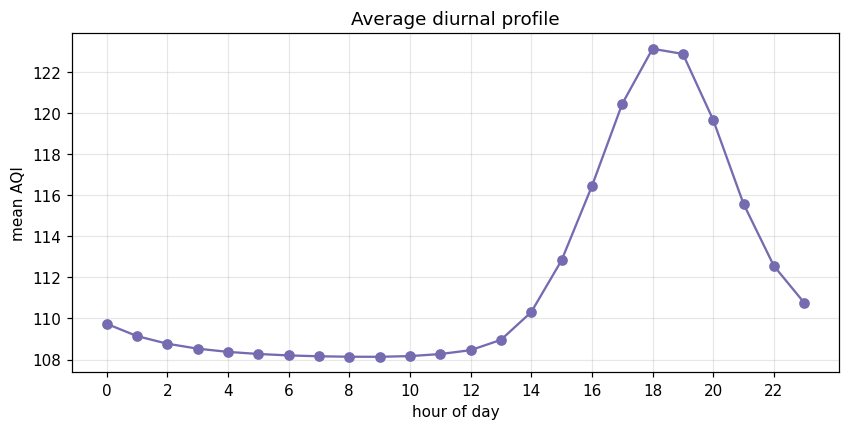

dirtiest hour: 18:00 (123.1)
cleanest hour: 09:00 (108.1)
within-day swing: 15.0 AQI points


In [7]:
diurnal = df.groupby("hour")["aqi"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(diurnal.index, diurnal.values, "-o", color="#756bb1")
ax.set(title="Average diurnal profile", xlabel="hour of day", ylabel="mean AQI", xticks=range(0, 24, 2))
plt.show()

print(f"dirtiest hour: {int(diurnal.idxmax()):02d}:00 ({diurnal.max():.1f})")
print(f"cleanest hour: {int(diurnal.idxmin()):02d}:00 ({diurnal.min():.1f})")
print(f"within-day swing: {diurnal.max() - diurnal.min():.1f} AQI points")

## 6. Weather is informative, but no single variable decidesThis is the argument for a non-linear model with interactions.

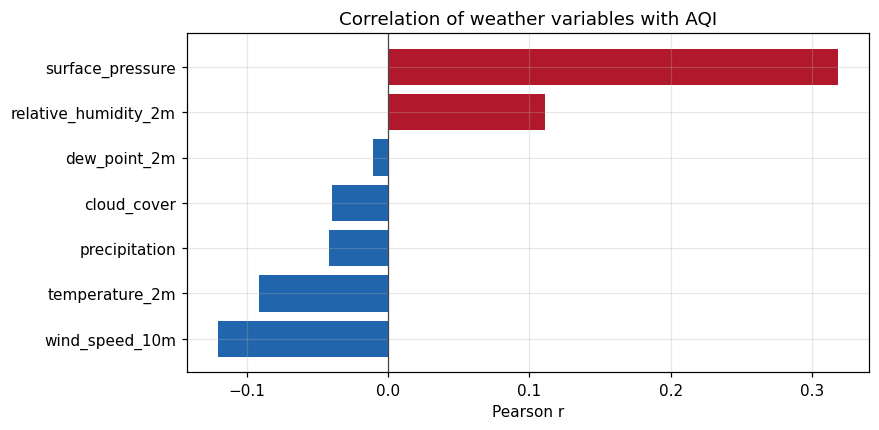

wind_speed_10m         -0.120
temperature_2m         -0.091
precipitation          -0.042
cloud_cover            -0.040
dew_point_2m           -0.011
relative_humidity_2m    0.111
surface_pressure        0.318

strongest |r| = 0.32 (surface_pressure)
No single driver explains the target -> tree ensemble over a linear model.


In [8]:
weather = ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "precipitation",
           "surface_pressure", "cloud_cover", "wind_speed_10m"]
corr = df[weather + ["aqi"]].corr()["aqi"].drop("aqi").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corr.index, corr.values, color=["#2166ac" if v < 0 else "#b2182b" for v in corr.values])
ax.axvline(0, color="#444", lw=0.8)
ax.set(title="Correlation of weather variables with AQI", xlabel="Pearson r")
plt.show()

print(corr.round(3).to_string())
print(f"\nstrongest |r| = {corr.abs().max():.2f} ({corr.abs().idxmax()})")
print("No single driver explains the target -> tree ensemble over a linear model.")

## 7. Autocorrelation: why lag features existAir quality is persistent, which is also why a persistence baseline is hard to beat at very short lead times.

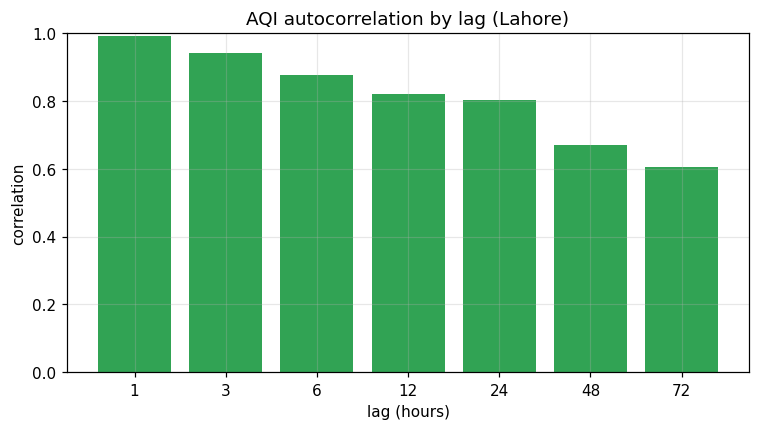

  lag  1h : 0.991
  lag  3h : 0.943
  lag  6h : 0.878
  lag 12h : 0.822
  lag 24h : 0.804
  lag 48h : 0.671
  lag 72h : 0.607

Still ~0.80 at 24h -> the daily cycle; motivates the 24h lag and rolling features.


In [9]:
lahore = df[df["city"] == "Lahore"].sort_values("datetime")["aqi"].reset_index(drop=True)
lags = [1, 3, 6, 12, 24, 48, 72]
ac = {h: lahore.autocorr(lag=h) for h in lags}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(h) for h in lags], [ac[h] for h in lags], color="#31a354")
ax.set(title="AQI autocorrelation by lag (Lahore)", xlabel="lag (hours)", ylabel="correlation", ylim=(0, 1))
plt.show()

for h in lags:
    print(f"  lag {h:>2}h : {ac[h]:.3f}")
print("\nStill ~{:.2f} at 24h -> the daily cycle; motivates the 24h lag and rolling features."
      .format(ac[24]))

## 8. Summary| Observation | Design consequence ||---|---|| 22 cities, mean AQI spread > 2x | Multi-city scope; a single global model conditioned on location || Winter/summer ratio well above 1 | Cyclical month encoding; seasonal drift is expected, not a fault || Large within-day swing | Cyclical hour encoding; hourly view in the dashboard || No dominant weather correlate | Gradient-boosted trees over a linear model || Strong autocorrelation | Lag and rolling features; persistence as the baseline to beat || Right-skewed target | Empirical residual quantiles for the 80% prediction interval |The figures written by `python -m aqi.eda` are in [`../docs/images/`](../docs/images), and thewritten summary is [`../docs/eda_findings.md`](../docs/eda_findings.md).